In [1]:
import kagglehub
import pandas as pd
import os

# Download latest version
path = kagglehub.dataset_download("uciml/sms-spam-collection-dataset")

print("Path to dataset files:", path)

# Check files inside the downloaded folder
print(os.listdir(path))

# Load dataset
df = pd.read_csv(os.path.join(path, "spam.csv"), encoding="latin-1")

Path to dataset files: C:\Users\DELL\.cache\kagglehub\datasets\uciml\sms-spam-collection-dataset\versions\1
['spam.csv']


In [2]:
# Show first 5 rows
df.head()

,v1,v2,Unnamed: 2,Unnamed: 3,Unnamed: 4
0,ham,"Go until jurong point, crazy.. Available only ...",NaN,NaN,NaN
1,ham,Ok lar... Joking wif u oni...,NaN,NaN,NaN
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,NaN,NaN,NaN
3,ham,U dun say so early hor... U c already then say...,NaN,NaN,NaN
4,ham,"Nah I don't think he goes to usf, he lives aro...",NaN,NaN,NaN


In [3]:
df.shape

(5572, 5)

# 5 Steps

In [4]:
# Data cleaning
# EDA
# Text preprocessing
# Model Building
# Evalution
# Improvement
# Convert into Website
# Deploy

# 1) Data Cleaning

In [5]:
df.columns

Index(['v1', 'v2', 'Unnamed: 2', 'Unnamed: 3', 'Unnamed: 4'], dtype='object')

In [6]:
# df['Unnamed: 2'].unique()
# df['Unnamed: 3'].unique()
# df['Unnamed: 4'].unique()
df.isnull().sum()

v1               0
v2               0
Unnamed: 2    5522
Unnamed: 3    5560
Unnamed: 4    5566
dtype: int64

In [7]:
df.drop(columns=['Unnamed: 2','Unnamed: 3','Unnamed: 4'],inplace=True)

In [8]:
df.head()

,v1,v2
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."


In [9]:
# Rename the columns
df.rename(columns={'v1':'Target','v2':'Text'},inplace=True)

In [10]:
from sklearn.preprocessing import LabelEncoder
encoder=LabelEncoder()
df['Target']=encoder.fit_transform(df['Target'])

In [11]:
df['Target'].unique()

array([0, 1])

In [12]:
df.duplicated().sum()

np.int64(403)

In [13]:
df=df.drop_duplicates(keep='first')

In [14]:
df.shape

(5169, 2)

# Exploratory Data Analysis

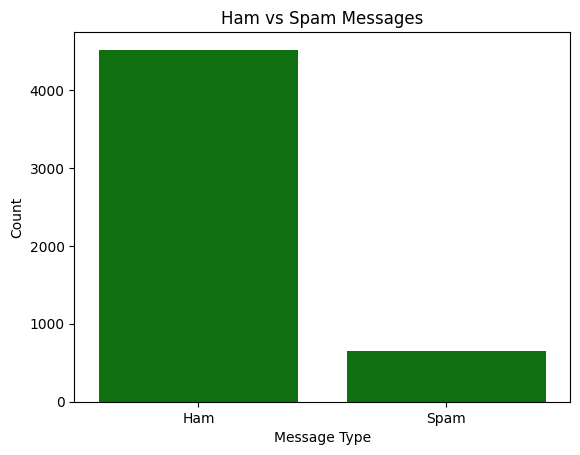

In [15]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.countplot(x="Target", data=df,color='green')

plt.xticks([0, 1], ["Ham", "Spam"])
plt.xlabel("Message Type")
plt.ylabel("Count")
plt.title("Ham vs Spam Messages")

plt.show()

In [16]:
df['Target'].value_counts()
# So data in Imbalanced

Target
0    4516
1     653
Name: count, dtype: int64

In [17]:
import nltk

In [18]:
nltk.download('punkt')

[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\DELL\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!


True

In [19]:
df = df.copy()

df["num_characters"] = df["Text"].apply(len)

df.head()

,Target,Text,num_characters
0,0,"Go until jurong point, crazy.. Available only ...",111
1,0,Ok lar... Joking wif u oni...,29
2,1,Free entry in 2 a wkly comp to win FA Cup fina...,155
3,0,U dun say so early hor... U c already then say...,49
4,0,"Nah I don't think he goes to usf, he lives aro...",61


In [20]:
df.head()

,Target,Text,num_characters
0,0,"Go until jurong point, crazy.. Available only ...",111
1,0,Ok lar... Joking wif u oni...,29
2,1,Free entry in 2 a wkly comp to win FA Cup fina...,155
3,0,U dun say so early hor... U c already then say...,49
4,0,"Nah I don't think he goes to usf, he lives aro...",61


In [21]:
import nltk
from nltk.tokenize import word_tokenize

df = df.copy()

df["Num_Words"] = df["Text"].apply(
    lambda x: len(word_tokenize(x))
)

df.head()

,Target,Text,num_characters,Num_Words
0,0,"Go until jurong point, crazy.. Available only ...",111,24
1,0,Ok lar... Joking wif u oni...,29,8
2,1,Free entry in 2 a wkly comp to win FA Cup fina...,155,37
3,0,U dun say so early hor... U c already then say...,49,13
4,0,"Nah I don't think he goes to usf, he lives aro...",61,15


In [22]:
from nltk.tokenize import sent_tokenize

df = df.copy()

df["Num_Sentences"] = df["Text"].apply(
    lambda x: len(sent_tokenize(x))
)

In [23]:
df.head()

,Target,Text,num_characters,Num_Words,Num_Sentences
0,0,"Go until jurong point, crazy.. Available only ...",111,24,2
1,0,Ok lar... Joking wif u oni...,29,8,2
2,1,Free entry in 2 a wkly comp to win FA Cup fina...,155,37,2
3,0,U dun say so early hor... U c already then say...,49,13,1
4,0,"Nah I don't think he goes to usf, he lives aro...",61,15,1


In [24]:
df[["num_characters", "Num_Words", "Num_Sentences"]].describe()

,num_characters,Num_Words,Num_Sentences
count,5169.000000,5169.000000,5169.000000
mean,78.977945,18.455794,1.965564
std,58.236293,13.324758,1.448541
min,2.000000,1.000000,1.000000
25%,36.000000,9.000000,1.000000
50%,60.000000,15.000000,1.000000
75%,117.000000,26.000000,2.000000
max,910.000000,220.000000,38.000000


In [25]:
# Describe function for Ham sms
df[df['Target']==0][["num_characters", "Num_Words", "Num_Sentences"]].describe()

,num_characters,Num_Words,Num_Sentences
count,4516.000000,4516.000000,4516.000000
mean,70.459256,17.123782,1.820195
std,56.358207,13.493970,1.383657
min,2.000000,1.000000,1.000000
25%,34.000000,8.000000,1.000000
50%,52.000000,13.000000,1.000000
75%,90.000000,22.000000,2.000000
max,910.000000,220.000000,38.000000


In [26]:
# Describe function for spam sms

df[df['Target']==1][["num_characters", "Num_Words", "Num_Sentences"]].describe()

,num_characters,Num_Words,Num_Sentences
count,653.000000,653.000000,653.000000
mean,137.891271,27.667688,2.970904
std,30.137753,7.008418,1.488425
min,13.000000,2.000000,1.000000
25%,132.000000,25.000000,2.000000
50%,149.000000,29.000000,3.000000
75%,157.000000,32.000000,4.000000
max,224.000000,46.000000,9.000000


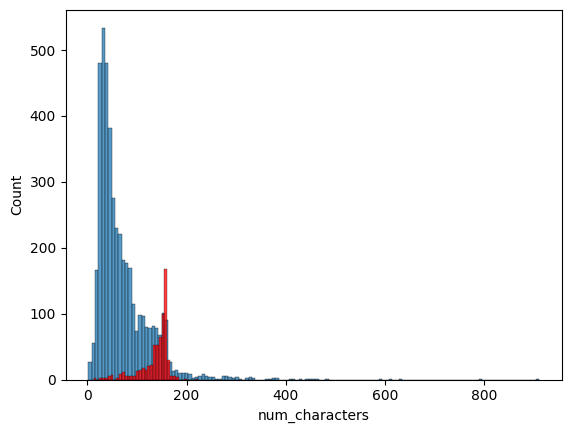

In [27]:
sns.histplot(df[df['Target']==0]["num_characters"])
sns.histplot(df[df['Target']==1]["num_characters"],color='red')
plt.show()

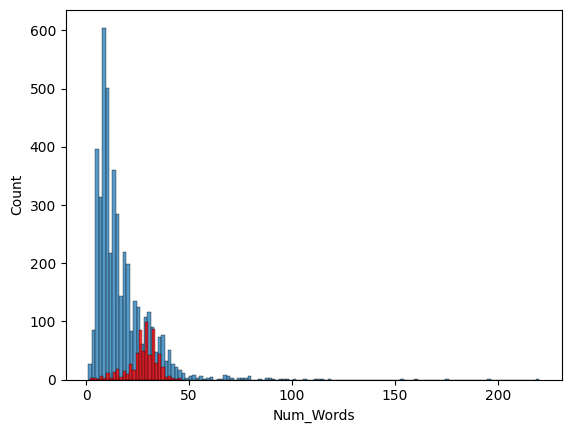

In [28]:
sns.histplot(df[df['Target']==0]["Num_Words"])
sns.histplot(df[df['Target']==1]["Num_Words"],color='red')
plt.show()

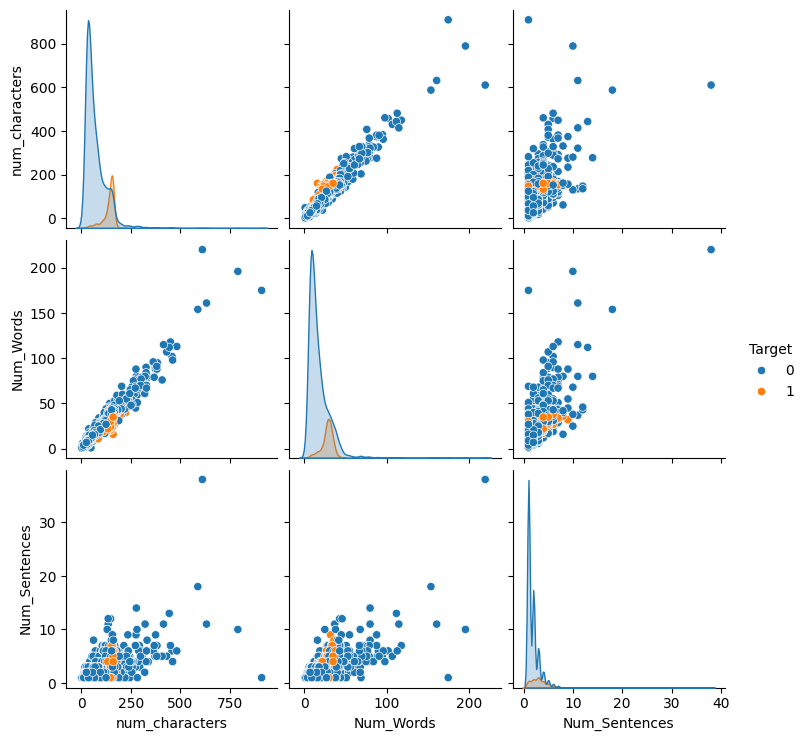

In [29]:
sns.pairplot(df,hue='Target')
plt.show()

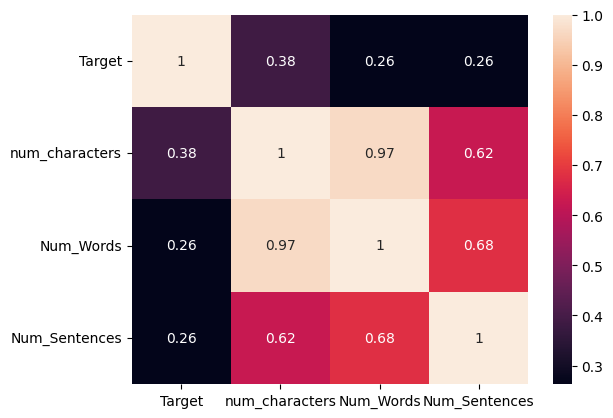

In [30]:
corr = df.select_dtypes(include="number").corr()

sns.heatmap(corr, annot=True)

plt.show()

# Data Pre-Processing

In [33]:
# lower case
# tokenizen (convert into words)
# remove stopwords and puncatuations
# remove special characters
# stemming

In [38]:
from nltk.stem.porter import PorterStemmer

ps = PorterStemmer()

def text_transform(text): 
    text = text.lower() 
    text = nltk.word_tokenize(text) 
 
    y = [] 
 
    for i in text: 
        if i.isalnum(): 
            y.append(i) 
 
    text = y[:] 
    y.clear() 
 
    for i in text: 
        if i not in stopwords.words('english') and i not in string.punctuation: 
            y.append(ps.stem(i)) 
         
    return " ".join(y) 
 
text_transform('HI HOW ARE YOU Shayan?')

'hi shayan'

In [41]:
df['Text'][15]

'XXXMobileMovieClub: To use your credit, click the WAP link in the next txt message or click here>> http://wap. xxxmobilemovieclub.com?n=QJKGIGHJJGCBL'

In [43]:
df['Transform_text']=df['Text'].apply(text_transform)

In [44]:
df.head()

,Target,Text,num_characters,Num_Words,Num_Sentences,Transform_text
0,0,"Go until jurong point, crazy.. Available only ...",111,24,2,go jurong point crazi avail bugi n great world...
1,0,Ok lar... Joking wif u oni...,29,8,2,ok lar joke wif u oni
2,1,Free entry in 2 a wkly comp to win FA Cup fina...,155,37,2,free entri 2 wkli comp win fa cup final tkt 21...
3,0,U dun say so early hor... U c already then say...,49,13,1,u dun say earli hor u c alreadi say
4,0,"Nah I don't think he goes to usf, he lives aro...",61,15,1,nah think goe usf live around though


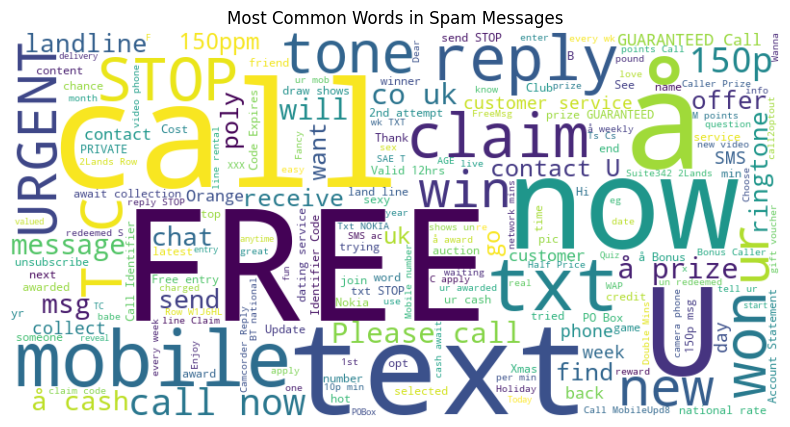

In [47]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt

spam_words = df[df["Target"] == 1]["Text"].str.cat(sep=" ")

wordcloud = WordCloud(
    width=800,
    height=400,
    background_color="white"
).generate(spam_words)

plt.figure(figsize=(10, 5))
plt.imshow(wordcloud, interpolation="bilinear")
plt.axis("off")
plt.title("Most Common Words in Spam Messages")
plt.show()

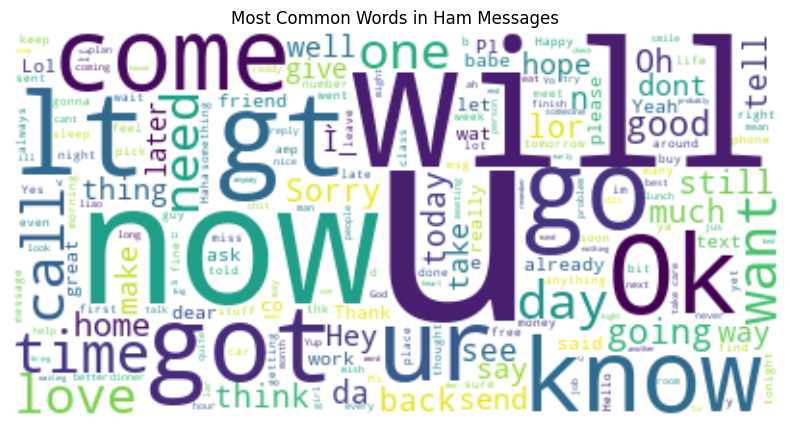

In [50]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt

ham_words = df[df["Target"] == 0]["Text"].str.cat(sep=" ")

wordcloud = WordCloud(
    width=400,
    height=200,
    background_color="white"
).generate(ham_words)

plt.figure(figsize=(10,5))
plt.imshow(wordcloud, interpolation="bilinear")
plt.axis("off")
plt.title("Most Common Words in Ham Messages")
plt.show()

In [57]:
from collections import Counter

spam_words = df[df["Target"] == 1]["Transform_text"].str.cat(sep=" ")

words = nltk.word_tokenize(spam_words.lower())

words = [word for word in words if word.isalnum() and word not in stopwords.words("english")]

top_30 = Counter(words).most_common(30)

top_30

[('call', 320),
 ('free', 191),
 ('2', 155),
 ('txt', 141),
 ('text', 122),
 ('u', 119),
 ('ur', 119),
 ('mobil', 114),
 ('stop', 104),
 ('repli', 103),
 ('claim', 98),
 ('4', 97),
 ('prize', 82),
 ('get', 74),
 ('new', 64),
 ('servic', 64),
 ('tone', 63),
 ('send', 60),
 ('urgent', 57),
 ('nokia', 57),
 ('contact', 56),
 ('award', 55),
 ('phone', 52),
 ('cash', 51),
 ('pleas', 51),
 ('week', 49),
 ('win', 48),
 ('c', 45),
 ('collect', 45),
 ('min', 45)]

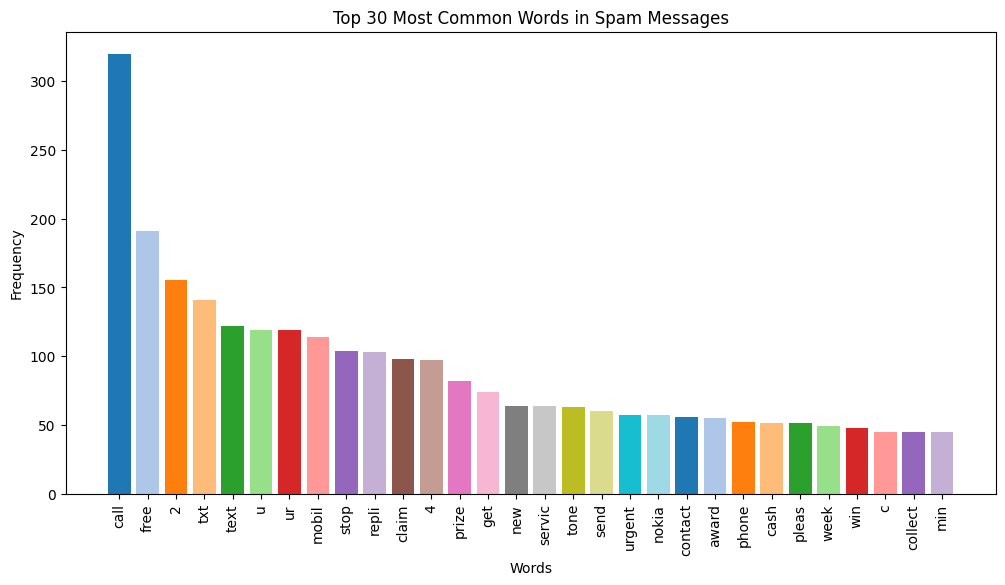

In [58]:
import matplotlib.pyplot as plt
import random

words = [word[0] for word in top_30]
counts = [word[1] for word in top_30]

colors = [plt.cm.tab20(i % 20) for i in range(30)]

plt.figure(figsize=(12, 6))
plt.bar(words, counts, color=colors)

plt.xticks(rotation=90)
plt.xlabel("Words")
plt.ylabel("Frequency")
plt.title("Top 30 Most Common Words in Spam Messages")

plt.show()

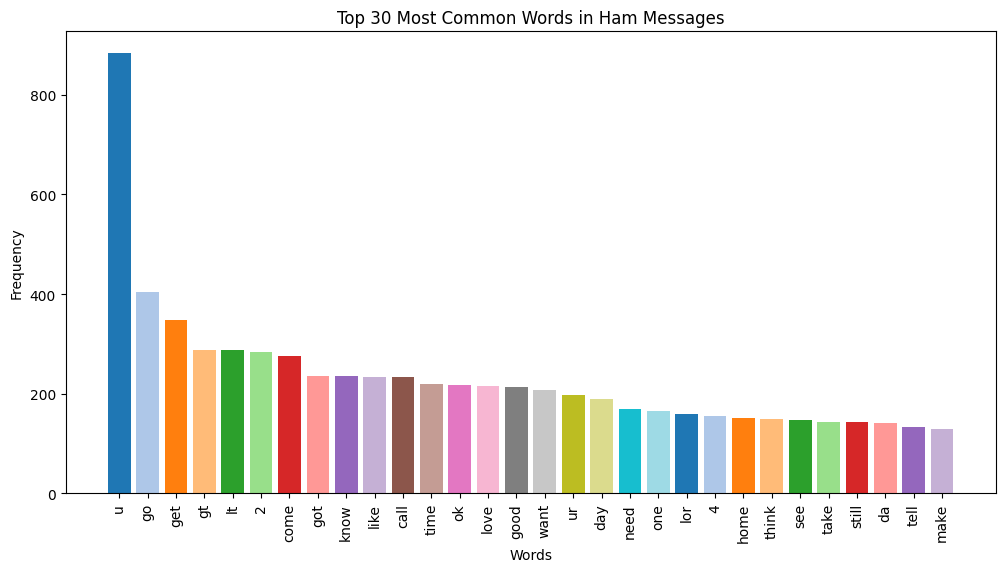

In [59]:
from collections import Counter
import nltk
import matplotlib.pyplot as plt

ham_words = df[df["Target"] == 0]["Transform_text"].str.cat(sep=" ")
words = nltk.word_tokenize(ham_words.lower())
words = [word for word in words if word.isalnum() and word not in stopwords.words("english")]

top_30_ham = Counter(words).most_common(30)

words = [word[0] for word in top_30_ham]
counts = [word[1] for word in top_30_ham]

colors = [plt.cm.tab20(i % 20) for i in range(30)]

plt.figure(figsize=(12, 6))
plt.bar(words, counts, color=colors)
plt.xticks(rotation=90)
plt.xlabel("Words")
plt.ylabel("Frequency")
plt.title("Top 30 Most Common Words in Ham Messages")
plt.show()

# Model Building 

In [60]:
from sklearn.feature_extraction.text import CountVectorizer

cv = CountVectorizer()

X = cv.fit_transform(df["Transform_text"]).toarray()

In [61]:
X.shape

(5169, 6708)

In [62]:
y=df['Target'].values

In [63]:
y

array([0, 0, 1, ..., 0, 0, 0], shape=(5169,))

In [64]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, df["Target"], test_size=0.2, random_state=2
)

In [65]:
from sklearn.naive_bayes import GaussianNB, MultinomialNB, BernoulliNB

gnb = GaussianNB()
mnb = MultinomialNB()
bnb = BernoulliNB()

## For GaussianNB

In [67]:
gnb.fit(X_train, y_train)

,priors,None
,var_smoothing,1e-09


In [68]:
y_pred_gnb = gnb.predict(X_test)

In [74]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

print("Accuracy:", round(accuracy_score(y_test, y_pred_gnb) * 100, 2), "%")
print("Precision:", round(precision_score(y_test, y_pred_gnb) * 100, 2), "%")
print("Recall:", round(recall_score(y_test, y_pred_gnb) * 100, 2), "%")
print("F1 Score:", round(f1_score(y_test, y_pred_gnb) * 100, 2), "%")
print()
print("Poor Performence by GaussianNB")

Accuracy: 88.01 %
Precision: 53.15 %
Recall: 85.51 %
F1 Score: 65.56 %

Poor Performence by GaussianNB


## For MultinomialNB

In [75]:
mnb.fit(X_train, y_train)
y_pred_mnb = mnb.predict(X_test)
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report

print("Accuracy:", round(accuracy_score(y_test, y_pred_mnb) * 100, 2), "%")
print("Precision:", round(precision_score(y_test, y_pred_mnb) * 100, 2), "%")
print("Recall:", round(recall_score(y_test, y_pred_mnb) * 100, 2), "%")
print("F1 Score:", round(f1_score(y_test, y_pred_mnb) * 100, 2), "%")

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_mnb))

Accuracy: 96.42 %
Precision: 83.44 %
Recall: 91.3 %
F1 Score: 87.2 %

Confusion Matrix:
[[871  25]
 [ 12 126]]


## For BernoulliNB

In [76]:
bnb.fit(X_train, y_train)
y_pred_bnb = bnb.predict(X_test)
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report

print("Accuracy:", round(accuracy_score(y_test, y_pred_bnb) * 100, 2), "%")
print("Precision:", round(precision_score(y_test, y_pred_bnb) * 100, 2), "%")
print("Recall:", round(recall_score(y_test, y_pred_bnb) * 100, 2), "%")
print("F1 Score:", round(f1_score(y_test, y_pred_bnb) * 100, 2), "%")

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_bnb))

Accuracy: 97.0 %
Precision: 97.35 %
Recall: 79.71 %
F1 Score: 87.65 %

Confusion Matrix:
[[893   3]
 [ 28 110]]


In [77]:
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf = TfidfVectorizer()

X = tfidf.fit_transform(df["Text"])

In [78]:
y=df['Target']

In [79]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, df["Target"], test_size=0.2, random_state=42
)

In [80]:
gnb.fit(X_train.toarray(), y_train)
y_pred_gnb = gnb.predict(X_test.toarray())

In [81]:
mnb.fit(X_train, y_train)
y_pred_mnb = mnb.predict(X_test)

In [82]:
bnb.fit(X_train, y_train)
y_pred_bnb = bnb.predict(X_test)

## GNB

In [84]:
print("Accuracy:", round(accuracy_score(y_test, y_pred_gnb) * 100, 2), "%")
print("Precision:", round(precision_score(y_test, y_pred_gnb) * 100, 2), "%")
print("Recall:", round(recall_score(y_test, y_pred_gnb) * 100, 2), "%")
print("F1 Score:", round(f1_score(y_test, y_pred_gnb) * 100, 2), "%")

Accuracy: 90.04 %
Precision: 60.29 %
Recall: 84.83 %
F1 Score: 70.49 %


## MNB

In [85]:
print("Accuracy:", round(accuracy_score(y_test, y_pred_mnb) * 100, 2), "%")
print("Precision:", round(precision_score(y_test, y_pred_mnb) * 100, 2), "%")
print("Recall:", round(recall_score(y_test, y_pred_mnb) * 100, 2), "%")
print("F1 Score:", round(f1_score(y_test, y_pred_mnb) * 100, 2), "%")

Accuracy: 95.55 %
Precision: 100.0 %
Recall: 68.28 %
F1 Score: 81.15 %


## BNB

In [86]:
print("Accuracy:", round(accuracy_score(y_test, y_pred_bnb) * 100, 2), "%")
print("Precision:", round(precision_score(y_test, y_pred_bnb) * 100, 2), "%")
print("Recall:", round(recall_score(y_test, y_pred_bnb) * 100, 2), "%")
print("F1 Score:", round(f1_score(y_test, y_pred_bnb) * 100, 2), "%")

Accuracy: 97.68 %
Precision: 97.64 %
Recall: 85.52 %
F1 Score: 91.18 %


In [51]:
df.columns

Index(['Target', 'Text', 'num_characters', 'Num_Words', 'Num_Sentences',
       'Transform_text'],
      dtype='object')

In [87]:
## Training of Models using Voting Methods

In [91]:
from sklearn.svm import SVC
from sklearn.naive_bayes import MultinomialNB
from sklearn.ensemble import ExtraTreesClassifier

svc = SVC(kernel='sigmoid', gamma=0.1, probability=True)
mnb = MultinomialNB()
etc = ExtraTreesClassifier(n_estimators=50, random_state=42)

In [92]:
from sklearn.ensemble import VotingClassifier

voting = VotingClassifier(
    estimators=[
        ('svc', svc),
        ('mnb', mnb),
        ('etc', etc)
    ],
    voting='soft'
)

voting.fit(X_train, y_train)

,estimators,"[('svc', ...), ('mnb', ...), ...]"
,voting,'soft'
,weights,None
,n_jobs,None
,flatten_transform,True
,verbose,False
,C,1.0
,kernel,'sigmoid'
,degree,3
,gamma,0.1
,coef0,0.0


In [93]:
y_pred_voting = voting.predict(X_test)

In [94]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

print("Accuracy:", round(accuracy_score(y_test, y_pred_voting) * 100, 2), "%")
print("Precision:", round(precision_score(y_test, y_pred_voting) * 100, 2), "%")
print("Recall:", round(recall_score(y_test, y_pred_voting) * 100, 2), "%")
print("F1 Score:", round(f1_score(y_test, y_pred_voting) * 100, 2), "%")

Accuracy: 98.55 %
Precision: 100.0 %
Recall: 89.66 %
F1 Score: 94.55 %


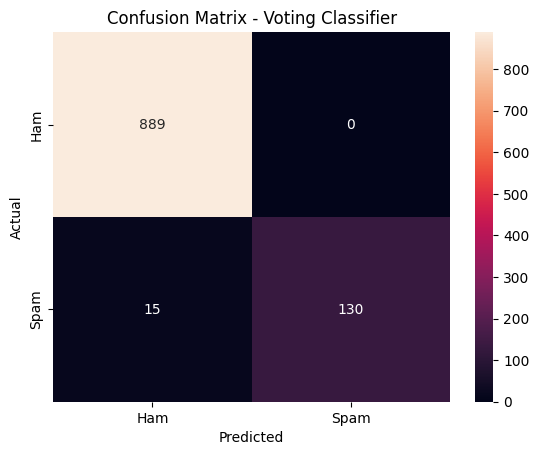

In [95]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred_voting)

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    xticklabels=["Ham", "Spam"],
    yticklabels=["Ham", "Spam"]
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - Voting Classifier")
plt.show()

In [96]:
import pickle

pickle.dump(voting, open("voting_model.pkl", "wb"))

In [97]:
pickle.dump(cv, open("vectorizer.pkl", "wb"))

In [98]:
import pickle

model = pickle.load(open("voting_model.pkl", "rb"))
vectorizer = pickle.load(open("vectorizer.pkl", "rb"))

In [100]:
cv = CountVectorizer()
X = cv.fit_transform(df["Text"])

X_train, X_test, y_train, y_test = train_test_split(
    X, df["Target"], test_size=0.2, random_state=42
)

voting.fit(X_train, y_train)

,estimators,"[('svc', ...), ('mnb', ...), ...]"
,voting,'soft'
,weights,None
,n_jobs,None
,flatten_transform,True
,verbose,False
,C,1.0
,kernel,'sigmoid'
,degree,3
,gamma,0.1
,coef0,0.0


In [101]:
import pickle

pickle.dump(voting, open("voting_model.pkl", "wb"))
pickle.dump(cv, open("vectorizer.pkl", "wb"))

In [102]:
import pickle

model = pickle.load(open("voting_model.pkl", "rb"))
vectorizer = pickle.load(open("vectorizer.pkl", "rb"))

In [103]:
message = ["Congratulations! You won a free prize."]

message_vector = vectorizer.transform(message)

print("Features:", message_vector.shape[1])

prediction = model.predict(message_vector)

if prediction[0] == 1:
    print("Spam")
else:
    print("Ham")

Features: 8672
Spam
